# SIMPLE TEXT CLASSIFICATION STEPS
*****************

* **SUMMARY OF DATA**

    - Total Samples
    - Total Features
    - Check Null Values
    - Check the balance of the target classes
**********
* **CLEANING** 

    - Drop Duplicates
    - Drop Null Values
    - Resampling for imbalanced classes
***************
* **TEXT PREPROCESSING**

    * Removing irrelevant words such as @mentions or http links etc.
    * Remove Punctuations
    * Lowercase 
*****************
* **VECTORIZATION**

    * Convert text into numerical features using Tf-idf
*************
* **MODEL TRAINING & EVALUATION**

    * Creating pipeline of simple models
****************
* **CONCLUSION**

    * Choosing model with best F1 score
*******************
* **PREDICTION**

    * Predicting on test dataset
******************
****************

# LOADING DATA

In [1]:
import pandas as pd
import numpy as np
import nltk
import spacy

In [2]:
train_df = pd.read_csv('../input/nlp-getting-started/train.csv')
train_df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


# SUMMARY OF DATA

In [3]:
print("Total Number of Samples ", len(train_df))
print("\nTotal Number of Features ", len(train_df.columns))

Total Number of Samples  7613

Total Number of Features  5


### Check for null data in the "text" column

In [4]:
train_df['text'].isna().any()

False

In [5]:
df = train_df[['id','text','target']]

In [6]:
df.target.value_counts()

0    4342
1    3271
Name: target, dtype: int64

### Check whether the target class is balanced or imbalanced

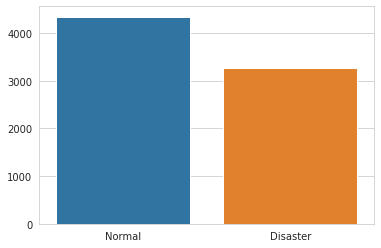

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

sns.barplot(x=['Normal','Disaster'], y= df.target.value_counts().values)
plt.show()

There is a slight difference between the two classes, so we can say it is balanced. Hence would not require any kind of resampling techniques.

# CLEANING
******************

* Drop Duplicates
* Drop Null Values

### Dropping Duplicates

In [8]:
import warnings
warnings.filterwarnings(action='ignore')

l = len(df)
df.drop_duplicates(subset='text', inplace=True)
print("Total Duplicates ", l - len(df))

Total Duplicates  110


In [9]:
len(df)

7503

### Dropping NaN Values

***************

There are no NaN values in the df

In [10]:
null_rows = df['text'][df['text'].isna()]
null_rows

Series([], Name: text, dtype: object)

# TEXT PREPROCESSING
*************

* Removing irrelevant words such as @mentions or http links etc.
* Remove Punctuations
* Lowercase 

In [11]:
import re

In [12]:
# helper function
def clean_text(text):
    te = str(text).encode('ascii','ignore').decode('UTF-8')
    te = re.sub(r'@[\w]+', '', te)
    te = re.sub(r'https?://t.co/[\w]+', '', te)
    te = re.sub(r'#', '', te)
    te = re.sub(r"RT @[\w]+:",'',te)
    te = re.sub(r"RT @[\w]+:",'',te)
    te = re.sub(r" RT ",'',te)
    te = re.sub(r"https://[\w]+.[\w]+/[\w]+",'',te)
    te = re.sub(r"[][]",'',te)
    te = re.sub(r"&amp","and", te)
    # remove the characters [\], ['] and ["]
    text = re.sub(r"\\", "", te)    
    text = re.sub(r"\'", "", text)    
    text = re.sub(r"\"", "", text)    
    
    # convert text to lowercase
    text = text.strip().lower()
    
    # replace punctuation characters with spaces
    filters='!"\'#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
    translate_dict = dict((c, " ") for c in filters)
    translate_map = str.maketrans(translate_dict)
    text = text.translate(translate_map)

    return text

# VECTORIZATION
*****************
* Convert the text into numerical features using Tf-idf

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
# Transform each text into a vector of word counts
vectorizer = TfidfVectorizer(stop_words="english",
                             preprocessor=clean_text,
                             ngram_range=(1, 2))

training_features = vectorizer.fit_transform(df.text)    

# MODEL TRAINING & EVALUATION

In [15]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, make_scorer, f1_score, accuracy_score
from sklearn.model_selection import KFold, cross_val_score

In [16]:
est = []
est.append(('LogisticRegression', Pipeline([('LR', LogisticRegression())])))
est.append(('BernoulliNB', Pipeline([('BNB', BernoulliNB())])))
est.append(('MultinomialNB', Pipeline([('MNB', MultinomialNB())])))
est.append(('LinearSVC', Pipeline([('LNB', LinearSVC())])))

In [17]:
%%time

# Training
model_scores = {}

p_scorer = make_scorer(precision_score)
r_scorer = make_scorer(recall_score)
f1_scorer = make_scorer(f1_score)
a_scorer = make_scorer(accuracy_score)

for i in est:
    kfold = KFold(n_splits=7, shuffle=True, random_state=4)
    p_scores = cross_val_score(i[1], training_features, df.target, cv=kfold, scoring=p_scorer)
    r_scores = cross_val_score(i[1], training_features, df.target, cv=kfold, scoring=r_scorer)
    f1_scores = cross_val_score(i[1], training_features, df.target, cv=kfold, scoring=f1_scorer)
    a_scores = cross_val_score(i[1], training_features, df.target, cv=kfold, scoring=a_scorer)
    
    model_scores.update({ i[0]:{'accuracy': a_scores.mean(), 'f1_score':f1_scores.mean(), 'precision': p_scores.mean(), 'recall':r_scores.mean()} })

CPU times: user 45.9 s, sys: 50 s, total: 1min 35s
Wall time: 27.8 s


In [18]:
for i in model_scores:
    print('\n', i)
    print('\n', model_scores[i])


 LogisticRegression

 {'accuracy': 0.7867510188154864, 'f1_score': 0.6913762678935791, 'precision': 0.9020825163884113, 'recall': 0.5611933646051182}

 BernoulliNB

 {'accuracy': 0.7823546085100707, 'f1_score': 0.6822734634350262, 'precision': 0.902549048840556, 'recall': 0.5491051718786335}

 MultinomialNB

 {'accuracy': 0.7990159994345997, 'f1_score': 0.7262441928404598, 'precision': 0.8653905380791863, 'recall': 0.6262223895962482}

 LinearSVC

 {'accuracy': 0.8016792537910687, 'f1_score': 0.7393408699826887, 'precision': 0.8411023438498465, 'recall': 0.6600685722663211}


# CONCLUSION
********************

* We will choose the model that gives the best F1 score which is a combination of precision and recall.

In [19]:
# model with top f1 score

top_models_score = sorted(model_scores.items(), key=lambda k:k[1]['f1_score'], reverse=True)
top_models_score[0]

('LinearSVC',
 {'accuracy': 0.8016792537910687,
  'f1_score': 0.7393408699826887,
  'precision': 0.8411023438498465,
  'recall': 0.6600685722663211})

In [20]:
top_model = dict(est)[top_models_score[0][0]]
top_model.fit(training_features, df.target)

Pipeline(steps=[('LNB', LinearSVC())])

# PREDICTION

In [21]:
# load test csv
test_df = pd.read_csv('../input/nlp-getting-started/test.csv')
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [22]:
test_features = vectorizer.transform(test_df.text)
predictions = top_model.predict(test_features)

In [23]:
submission = pd.DataFrame(columns=['id', 'target'])
submission['id'] = test_df['id']
submission['target'] = predictions

submission.to_csv('submission.csv', index=False)